In [2]:
import matplotlib as mpl
import seaborn as sns
import importlib

# Seaborn theme
sns.set_theme(
    style="ticks",        # "white", "whitegrid", "ticks", "darkgrid"
    context="paper",       # notebook, paper, talk, poster
    palette="deep"
)

# Your publication formatting
mpl.rcParams.update({

    # Fonts
    "font.family": "Arial",
    "font.size": 14,

    # Figure titles
    "figure.titlesize": 34,
    "figure.titleweight": "bold",

    # Axes titles/labels
    "axes.titlesize": 14,
    "axes.labelsize": 14,

    # Tick labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,

    # Legend
    "legend.fontsize": 16,
    "legend.title_fontsize": 18,

    # Lines & markers
    "lines.linewidth": 3,
    "lines.markersize": 8,

    # Axes
    "axes.linewidth": 2,

    # Ticks
    "xtick.major.size": 8,
    "ytick.major.size": 8,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.minor.width": 1.5,
    "ytick.minor.width": 1.5,

    # Grid
    "grid.linewidth": 1,
    "grid.alpha": 0.3,

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 600,

    # Editable vector graphics
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

# Supplement — Numerical and boundary convergence

Tests escape height, lattice spacing, lateral domain size, and observation horizon. Each condition is paired to its same-seed baseline replicate.


In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "analysis_tools":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from analysis_tools.manuscript_escape_analysis import (
    classical_occupancy, condition_statistics, discover_runs,
    load_receptor_summaries, occupancy_from_bound_time,
    replicate_survival_curves, save_figure, summarize_replicates,
)

SAVE_FIGURES = False
FIGURE_ROOT = PROJECT_ROOT / "analysis_tools" / "manuscript_panels"


In [4]:
DATA_ROOT="/Users/rynon/Library/CloudStorage/OneDrive-NorthwesternUniversity/PhD/Data/Agent-based simulations/261005_manuscript_supp_numerical_convergence"
index=discover_runs(DATA_ROOT)
replicates=summarize_replicates(index)
baseline=replicates.loc[replicates.test_parameter.eq("baseline"),["replicate","mean_bound_time_s","mean_rebindings","affinity_shift_fold","censoring_fraction"]].set_index("replicate").add_suffix("_baseline")
paired=replicates.join(baseline,on="replicate")
for metric in ["mean_bound_time_s","mean_rebindings","affinity_shift_fold"]:
    paired[f"{metric}_ratio"] = paired[metric]/paired[f"{metric}_baseline"]
display(paired[["condition_label","replicate","test_parameter","test_value","censoring_fraction","mean_bound_time_s_ratio","mean_rebindings_ratio","affinity_shift_fold_ratio"]])


,condition_label,replicate,test_parameter,test_value,censoring_fraction,mean_bound_time_s_ratio,mean_rebindings_ratio,affinity_shift_fold_ratio
0,baseline,1,baseline,1.000000e+00,0.000000,1.000000,1.000000,1.000000
1,baseline,2,baseline,1.000000e+00,0.000000,1.000000,1.000000,1.000000
2,baseline,3,baseline,1.000000e+00,0.000000,1.000000,1.000000,1.000000
3,baseline,4,baseline,1.000000e+00,0.000000,1.000000,1.000000,1.000000
4,escape_z_65nm,1,escape_z_m,6.500000e-08,0.000000,0.783467,0.720275,0.783467
5,escape_z_65nm,2,escape_z_m,6.500000e-08,0.000000,0.786734,0.724999,0.786734
6,escape_z_65nm,3,escape_z_m,6.500000e-08,0.000000,0.787039,0.719179,0.787039
7,escape_z_65nm,4,escape_z_m,6.500000e-08,0.000000,0.785387,0.718744,0.785387
8,escape_z_90nm,1,escape_z_m,9.000000e-08,0.000000,1.326276,1.423064,1.326276
9,escape_z_90nm,2,escape_z_m,9.000000e-08,0.000000,1.329285,1.423866,1.329285


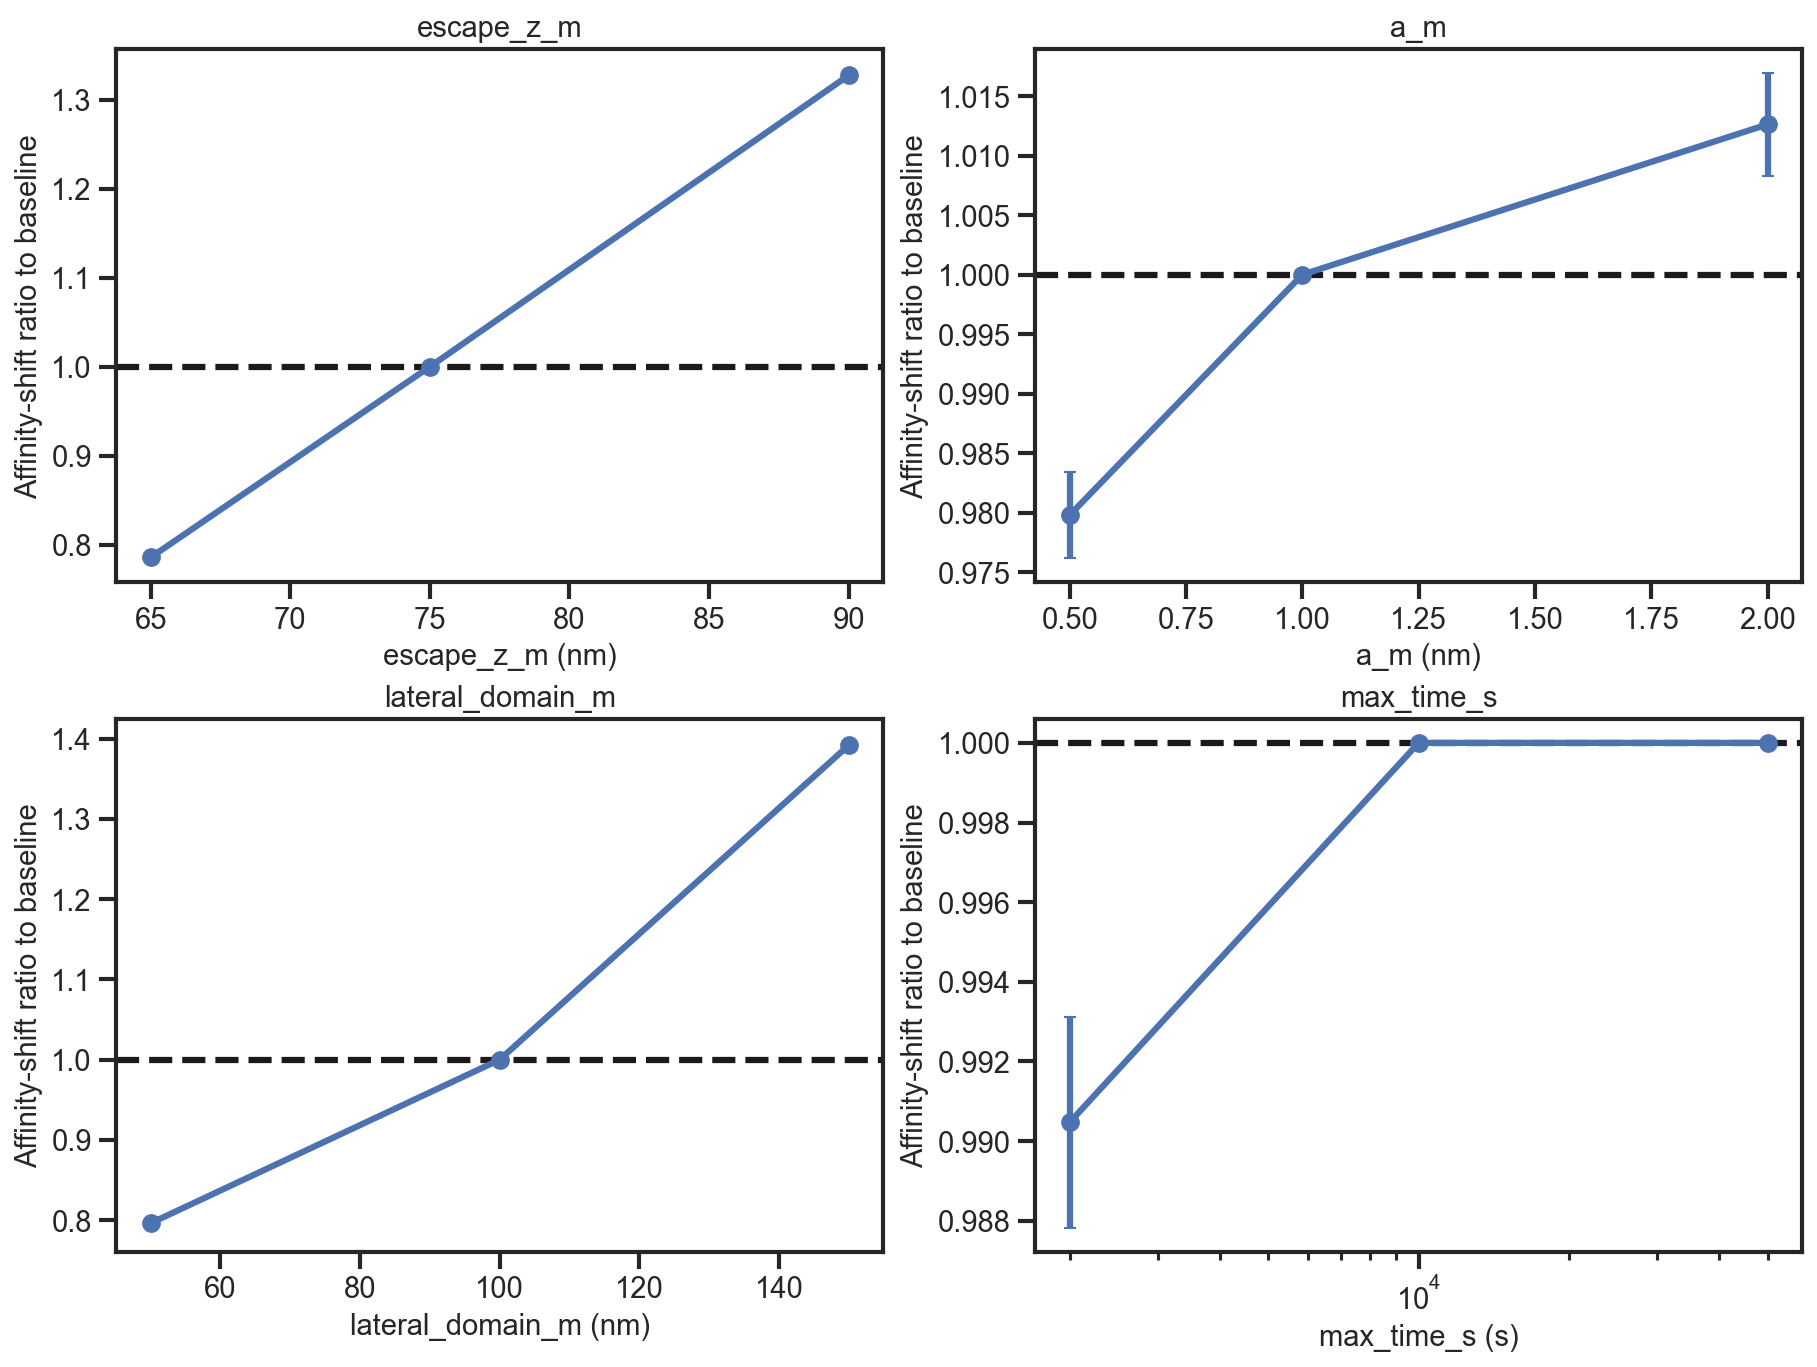

In [5]:
parameters=["escape_z_m","a_m","lateral_domain_m","max_time_s"]
fig,axes=plt.subplots(2,2,figsize=(12,9),constrained_layout=True)
for ax,parameter in zip(axes.flat,parameters):
    frame=paired.loc[paired.test_parameter.isin([parameter,"baseline"])].copy()
    if parameter=="escape_z_m": frame.loc[frame.test_parameter.eq("baseline"),"test_value"]=75e-9
    elif parameter=="a_m": frame.loc[frame.test_parameter.eq("baseline"),"test_value"]=1e-9
    elif parameter=="lateral_domain_m": frame.loc[frame.test_parameter.eq("baseline"),"test_value"]=100e-9
    elif parameter=="max_time_s": frame.loc[frame.test_parameter.eq("baseline"),"test_value"]=10000
    summary=frame.groupby("test_value").affinity_shift_fold_ratio.agg(["mean","sem"]).reset_index().sort_values("test_value")
    scale=1e9 if parameter in {"escape_z_m","a_m","lateral_domain_m"} else 1
    ax.errorbar(summary.test_value*scale,summary["mean"],yerr=summary["sem"],marker="o",capsize=3)
    ax.axhline(1,color="k",ls="--"); ax.set(xlabel=parameter+(" (nm)" if scale==1e9 else " (s)"),ylabel="Affinity-shift ratio to baseline",title=parameter)
    if parameter=="max_time_s": ax.set_xscale("log")
if SAVE_FIGURES: save_figure(fig,FIGURE_ROOT,"supp_numerical_convergence")
plt.show()


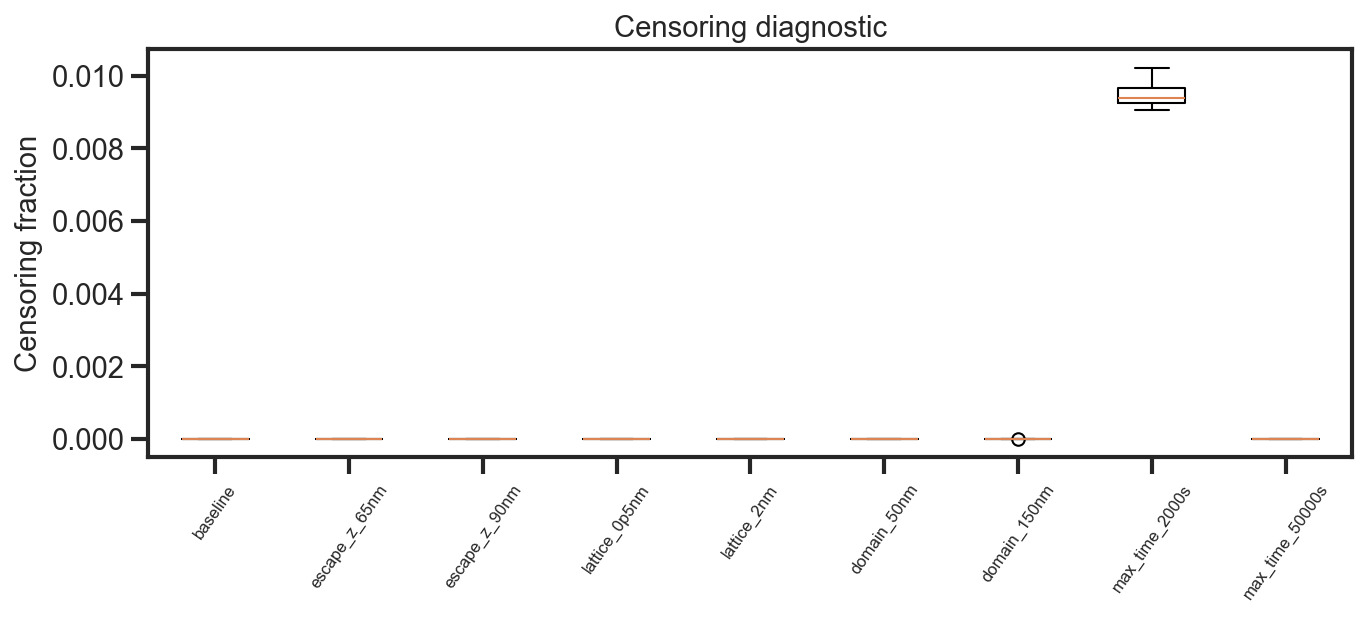

In [6]:
fig,ax=plt.subplots(figsize=(9,4),constrained_layout=True)
order=paired.groupby("condition_index").condition_label.first().sort_index().tolist()
ax.boxplot([paired.loc[paired.condition_label.eq(x),"censoring_fraction"] for x in order],tick_labels=order)
ax.set(ylabel="Censoring fraction",title="Censoring diagnostic"); plt.setp(ax.get_xticklabels(),rotation=45,ha="right",rotation_mode="anchor")
plt.show()
